In [1]:
import pandas as pd
import numpy as np
import os

from kornia.metrics import confusion_matrix

In [2]:
data_root = '/home/dhruvagarwal/projects/MitoSpace4D/runs/lightning_logs/resnetbilistm_encoder_consistent_temporal/embeddings_kinetics_data_60frames/'

print("Loading data...")
emb = np.load(os.path.join(data_root, "embeddings.npy"))         # (N, 60, 2048)
# emb = emb[:, [-1], :]
print(emb.shape)
labels = np.load(os.path.join(data_root, "labels.npy"))     
print(labels)
img_paths = np.load(os.path.join(data_root, "image_file_paths.npy"))
print(img_paths)

Loading data...
(11424, 60, 2048)
[13 16  7 ...  7 11  1]
['/mnt/aquila/ssd_processing/Others/MitoSpace4D/2025_kinetics_data/processed_data/20250722-2/000169-0.npy'
 '/mnt/aquila/ssd_processing/Others/MitoSpace4D/2025_kinetics_data/processed_data/20250728-1/000225-0.npy'
 '/mnt/aquila/ssd_processing/Others/MitoSpace4D/2025_kinetics_data/processed_data/20250829-2/000166-0.npy'
 ...
 '/mnt/aquila/ssd_processing/Others/MitoSpace4D/2025_kinetics_data/processed_data/20250829-2/000044-0.npy'
 '/mnt/aquila/ssd_processing/Others/MitoSpace4D/2025_kinetics_data/processed_data/20250806-2/000245-0.npy'
 '/mnt/aquila/ssd_processing/Others/MitoSpace4D/2025_kinetics_data/processed_data/20250806-1/000306-0.npy']


In [3]:
df = pd.DataFrame({
    'img_path': img_paths,
    'label': labels,
    'embedding': list(emb)
})

In [4]:
# sort by img_path
df = df.sort_values(by='img_path').reset_index(drop=True)
df.head(10)

,img_path,label,embedding
0,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[[0.02245179, 0.0037415768, -0.02442164, 0.049..."
1,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[[0.02510606, 0.0064678616, -0.021704333, 0.05..."
2,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[[0.019094273, 0.009159361, -0.024241548, 0.05..."
3,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[[0.022421319, 0.008701455, -0.022447567, 0.05..."
4,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[[0.039226707, -0.0032152478, -0.021055993, 0...."
5,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[[0.030229796, 0.0023671396, -0.023048839, 0.0..."
6,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[[0.02295894, 0.0065786275, -0.026344469, 0.05..."
7,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[[0.032801643, -0.0038612979, -0.021514304, 0...."
8,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[[0.040510006, -0.004117702, -0.019049184, 0.0..."
9,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[[0.02596865, 0.004011576, -0.026461078, 0.050..."


In [5]:
# add pseudo region_id to each row based on img_path: for every label, divide the rows into groups of 30
df['region_id'] = df.groupby('label').cumcount() // 30
df.head(300)
print(df['region_id'].value_counts())

# lets filter only region 0
df = df[df['region_id'] == 0]
print(df['region_id'].value_counts())

region_id
0     780
6     780
1     780
8     780
7     780
9     780
5     780
4     780
3     780
2     780
10    779
11    737
12    650
13    566
14    374
15    271
16    174
17     54
18     19
Name: count, dtype: int64
region_id
0    780
Name: count, dtype: int64


In [6]:
# now expand by timepoints
df_expanded = df.explode('embedding').reset_index(drop=True)
df_expanded.head(600)

,img_path,label,embedding,region_id
0,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.02245179, 0.0037415768, -0.02442164, 0.0491...",0
1,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.012409239, 0.006258555, -0.02111276, 0.0452...",0
2,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.020671558, 0.004669683, -0.013162091, 0.050...",0
3,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.011252227, 0.0067091007, -0.006383998, 0.04...",0
4,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.016278634, 0.0031048956, -0.006254413, 0.05...",0
...,...,...,...,...
595,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[-0.008149113, 0.0040448215, 0.00028944868, 0....",0
596,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.0069532255, -0.0010241552, 0.0011501139, 0....",0
597,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[-0.00989373, 0.0037931812, 0.00020563902, 0.0...",0
598,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.003743254, -0.0007872133, 0.0011891762, 0.0...",0


In [7]:
# add timepoint column
df_expanded['timepoint'] = df_expanded.groupby('img_path').cumcount()
df_expanded.head(10)

,img_path,label,embedding,region_id,timepoint
0,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.02245179, 0.0037415768, -0.02442164, 0.0491...",0,0
1,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.012409239, 0.006258555, -0.02111276, 0.0452...",0,1
2,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.020671558, 0.004669683, -0.013162091, 0.050...",0,2
3,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.011252227, 0.0067091007, -0.006383998, 0.04...",0,3
4,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.016278634, 0.0031048956, -0.006254413, 0.05...",0,4
5,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.008069607, 0.0048995186, -0.0053116665, 0.0...",0,5
6,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.01559836, 0.00038698735, -0.0048677707, 0.0...",0,6
7,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.00451547, 0.0018950541, -0.0039747288, 0.05...",0,7
8,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.0142109655, -0.0012945863, -0.004650627, 0....",0,8
9,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.0048972336, 0.0012574617, -0.0038048842, 0....",0,9


In [8]:
# now add a actual time column based on region_id and timepoint
df_expanded['time'] = df_expanded['region_id'] * 60 + df_expanded['timepoint']
df_expanded.head(10)

,img_path,label,embedding,region_id,timepoint,time
0,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.02245179, 0.0037415768, -0.02442164, 0.0491...",0,0,0
1,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.012409239, 0.006258555, -0.02111276, 0.0452...",0,1,1
2,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.020671558, 0.004669683, -0.013162091, 0.050...",0,2,2
3,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.011252227, 0.0067091007, -0.006383998, 0.04...",0,3,3
4,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.016278634, 0.0031048956, -0.006254413, 0.05...",0,4,4
5,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.008069607, 0.0048995186, -0.0053116665, 0.0...",0,5,5
6,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.01559836, 0.00038698735, -0.0048677707, 0.0...",0,6,6
7,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.00451547, 0.0018950541, -0.0039747288, 0.05...",0,7,7
8,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.0142109655, -0.0012945863, -0.004650627, 0....",0,8,8
9,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.0048972336, 0.0012574617, -0.0038048842, 0....",0,9,9


In [31]:
control_df = df_expanded[df_expanded['label'] == 5].reset_index(drop=True)
len(control_df)

1800

(300, 300)


/home/dhruvagarwal/anaconda3/envs/deeplearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhruvagarwal/anaconda3/envs/deeplearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhruvagarwal/anaconda3/envs/deeplearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhruvagarwal/anaconda3/

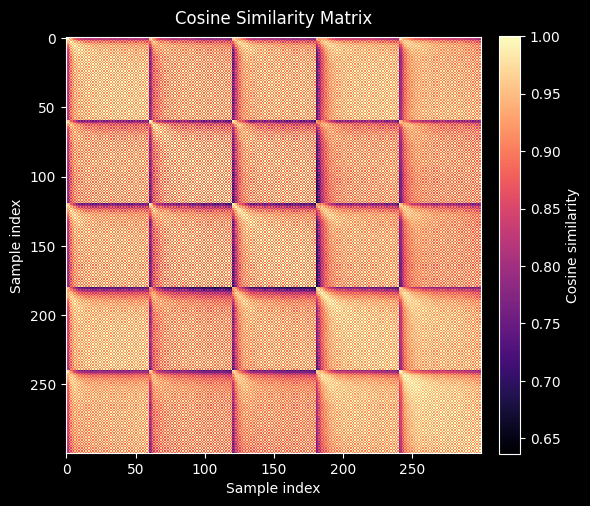

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Optional: use a built-in dark style
plt.style.use("dark_background")

first_5_regions_control = control_df['embedding'][:60*5]
first_5_regions_control = np.array([x for x in np.array(first_5_regions_control)])

cos_dist = np.dot(first_5_regions_control, first_5_regions_control.T)
print(cos_dist.shape)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    cos_dist,
    cmap="magma",      
    interpolation="nearest"
)

# Add colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Cosine similarity", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")

# Titles & labels
ax.set_title("Cosine Similarity Matrix", color="white", pad=10)
ax.set_xlabel("Sample index", color="white")
ax.set_ylabel("Sample index", color="white")

# Make ticks readable
ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

In [16]:
drug_labels_dict = {}
label_drug_dict = {}
with open(f"/home/dhruvagarwal/projects/MitoSpace4D/extraction_utils/drugs_to_labels_new.txt", 'r') as f:
    for line in f:
        folder, drug, label = line.split()
        drug_labels_dict[drug] = int(label)
        label_drug_dict[int(label)] = drug

In [17]:
# map labels to drug names
df_expanded['drug'] = df_expanded['label'].map(label_drug_dict)
df_expanded.head(10)

,img_path,label,embedding,region_id,timepoint,time,drug
0,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.02245179, 0.0037415768, -0.02442164, 0.0491...",0,0,0,mitomycinc
1,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.012409239, 0.006258555, -0.02111276, 0.0452...",0,1,1,mitomycinc
2,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.020671558, 0.004669683, -0.013162091, 0.050...",0,2,2,mitomycinc
3,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.011252227, 0.0067091007, -0.006383998, 0.04...",0,3,3,mitomycinc
4,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.016278634, 0.0031048956, -0.006254413, 0.05...",0,4,4,mitomycinc
5,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.008069607, 0.0048995186, -0.0053116665, 0.0...",0,5,5,mitomycinc
6,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.01559836, 0.00038698735, -0.0048677707, 0.0...",0,6,6,mitomycinc
7,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.00451547, 0.0018950541, -0.0039747288, 0.05...",0,7,7,mitomycinc
8,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.0142109655, -0.0012945863, -0.004650627, 0....",0,8,8,mitomycinc
9,/mnt/aquila/ssd_processing/Others/MitoSpace4D/...,13,"[0.0048972336, 0.0012574617, -0.0038048842, 0....",0,9,9,mitomycinc


In [18]:
df_expanded.to_parquet('/home/dhruvagarwal/projects/MitoSpace4D/runs/lightning_logs/resnetbilistm_encoder_consistent_temporal/embeddings_kinetics_data_60frames/expanded_embeddings_with_time.parquet', index=False)

In [54]:
df_expanded.to_csv('/home/dhruvagarwal/projects/MitoSpace4D/runs/lightning_logs/resnetbilistm_encoder_consistent_temporal/embeddings_kinetics_data_60frames/expanded_embeddings_with_time.csv', index=False)